## **EXPLORAÇÃO, ANÁLISE E TRATAMENTO DOS DADOS: DataSet -> Adult Income** ###

### 1.- **Introdução e Objetivos** ###

 - O objetivo é preparar a Base de Dados Adult Income antes de ser inserida nos algoritmos de classificação. Ao Final destes script, será exportado o aqruivo 'adult_tratado.csv' para que posteriormente seja utilizado nos algoritmos de classificação


O dataset "adult Income" é um conjunto de dados amplamente utilizado para tarefas de classificação em aprendizado de máquina. O objetivo principal é prever se a renda de um indivíduo excede US$ 50K por ano com base em diversos atributos demográficos e socioeconômicos. 


Visão Geral do Dataset:
 - Objetivo: Prever se a renda de um indivíduo é ">50K" ou "<=50K" por ano.
 - Número de Atributos: 14 atributos (além da variável alvo 'income').
 - Tipos de Atributos: Categóricos e Contínuos.
 - Valores Ausentes: O dataset original possui valores ausentes representados por "?".


### 2.- **Exploração dos Dados** ###

####   2.1-- *Importando as Bibliotecas para exploração e análise dos dados* ####

In [72]:
# Importando as Bibliotecas para exploração e análise dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#### 2.2-- *Análise inicial do DataFrame* ####

In [73]:
# Carregamento da base de dados Adult em um DataFrame
dataset = pd.read_csv("adult.data", header= None, na_values="?", skipinitialspace=True)
dataset.head() # Como pode Ser abservado são 15 colunas. 14 colunas de atributos (previsoras) e a coluna Alvo (Target)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [74]:
# Numeros de Linhas e Colunas (Dataset -> Original)
dataset.shape

(32561, 15)

In [75]:
# Adicionar nomes das colunas (de acordo com a base oficial)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
dataset.columns = columns # Nomeando as colunas conforme lista Columns
dataset.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [76]:
dataset.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

### 3.- **Valores Faltantes** ###

In [77]:
dataset.isnull().sum() # Valores Faltantes

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [78]:
print('(Linhas x Colunas):')
print("Antes de Remover as linhas com dados faltantes (simbolo -> ?):",dataset.shape)
# Remover linhas com valores faltantes
dataset.dropna(inplace=True)

print('(Linhas x Colunas):')
print("Após Remover as linhas com dados faltantes (simbolo -> ?):",dataset.shape)
dataset.head()

(Linhas x Colunas):
Antes de Remover as linhas com dados faltantes (simbolo -> ?): (32561, 15)
(Linhas x Colunas):
Após Remover as linhas com dados faltantes (simbolo -> ?): (30162, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [79]:
# RELAÇÃO DA QUANTIDADE
dataset.isnull().sum() # Valores Faltantes

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### 4.- **Análise das Variáveis** ###

#### --   *Resumo do Atributos (Features)* ####

1. age: Idade do indivíduo (contínuo).
2. workclass: Classe de trabalhador (categórico): Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
3. fnlwgt: Peso final, representando o número de indivíduos que as autoridades do censo acreditam que essa entrada representa (contínuo).
4. education: Nível de escolaridade do indivíduo (categórico): Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters,  1st-4th, 10th, Doctorate, 5th-6th, Preschool.
5. education-num: Número de anos de educação alcançados (contínuo).
6. marital-status: Estado civil do indivíduo (categórico): Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
7. occupation: Ocupação do indivíduo (categórico): Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
8. relationship: Relação familiar do indivíduo (categórico): Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
9. race: Raça do indivíduo (categórico): White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
10. sex: Sexo do indivíduo (categórico): Female, Male.
11. capital-gain: Ganho de capital (contínuo).
12. capital-loss: Perda de capital (contínuo).
13. hours-per-week: Número de horas trabalhadas por semana (contínuo).
14. native-country: País de origem do indivíduo (categórico): United-States, Cuba, Jamaica, Germany, England, Canada, India, Japan, Greece, South, China, Scotland, Italy, Thailand, Hong-Kong, Philippines, Iran, Vietnam, Mexico, Puerto-Rico, Poland, Honduras, El-Salvador, Yugoslavia, Outlying-US(Guam-USVI-etc), Peru, Guatemala, Dominican-Republic, Ireland, Hungary, Columbia, Holand-Netherlands.
15. income: Variável alvo (categórico): >50K, <=50K.

#### 4.1- Age : Idade do indivíduo ####


##### 4.1.1- Dados e Estatisticas #####

Representa a idade do indivíduo e é uma variável numérica contínua.
*Importância do atributo age*
- Pode influenciar a renda: Pessoas mais velhas tendem a ter mais experiência profissional, o que pode impactar seus ganhos.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e horas trabalhadas por semana.


In [80]:
dataset.age.value_counts().sort_index()

age
17    328
18    447
19    594
20    629
21    621
     ... 
84      8
85      3
86      1
88      3
90     35
Name: count, Length: 72, dtype: int64

In [81]:
dataset.age.describe()

count    30162.000000
mean        38.437902
std         13.134665
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64

##### 4.1.2- Gráfico #####

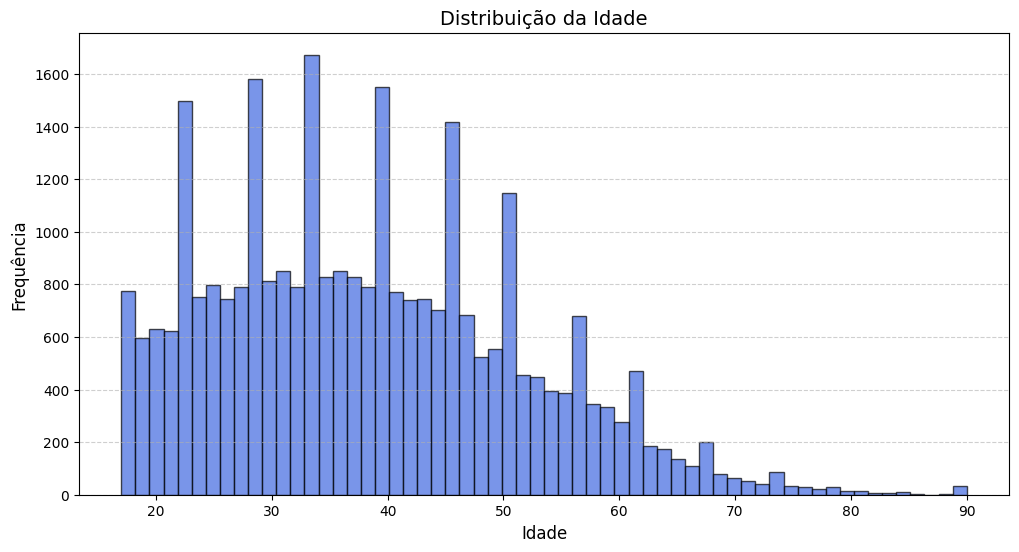

In [82]:
plt.figure(figsize=(12, 6))  
plt.hist(dataset.age, bins=60, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição da Idade", fontsize=14)
plt.xlabel("Idade", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

# Ajustando o estilo do grid para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

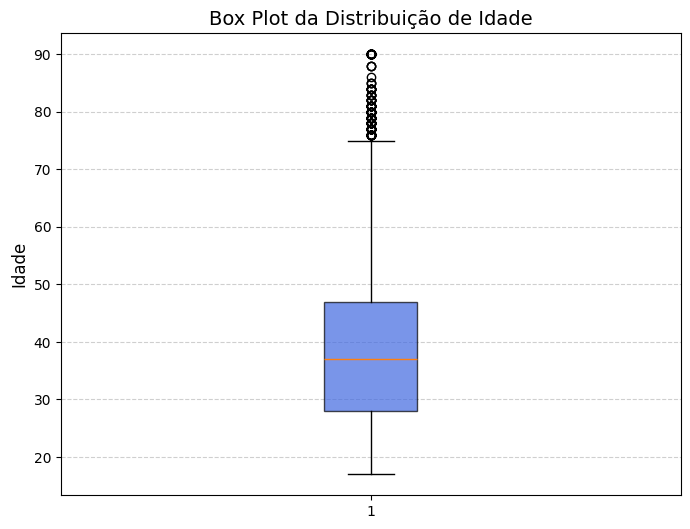

In [83]:
plt.figure(figsize=(8, 6))
plt.boxplot(dataset.age, vert=True, patch_artist=True, boxprops=dict(facecolor='royalblue', alpha=0.7))

# Adicionando título e rótulos
plt.title("Box Plot da Distribuição de Idade", fontsize=14)
plt.ylabel("Idade", fontsize=12)


plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

1. Mediana:
- Está aproximadamente em 37 anos, indicando que metade da população tem menos de 37 anos e a outra metade mais.

2. Quartis:
- Q1 (25%) ≈ 28 anos

- Q3 (75%) ≈ 47 anos

- Isso mostra que 50% dos dados estão entre 28 e 47 anos, o que representa a faixa etária mais comum (distribuição central).

3. Intervalo interquartil (IQR):
- IQR = Q3 - Q1 ≈ 47 - 28 = 19 anos

4. Mínimo e Máximo (sem outliers):
- A idade mínima (sem considerar outliers) parece estar em torno de 17 anos

- A idade máxima (sem considerar outliers) está em torno de 74 anos

5. Outliers (valores fora do padrão):
- Há vários outliers acima de 74 anos, indo até 90 anos

- Esses pontos representam uma parcela pequena, mas importante da população, e podem indicar:

- Pessoas ainda economicamente ativas em idade avançada


#### 4.2- Workclass : Classe de trabalhador, indica o tipo de empregador  ####

##### 4.2.1- Dados #####

In [84]:
cont_worclass = dataset.workclass.value_counts()
cont_worclass.sort_index()


workclass
Federal-gov           943
Local-gov            2067
Private             22286
Self-emp-inc         1074
Self-emp-not-inc     2499
State-gov            1279
Without-pay            14
Name: count, dtype: int64

##### 4.2.2- Gráfico #####

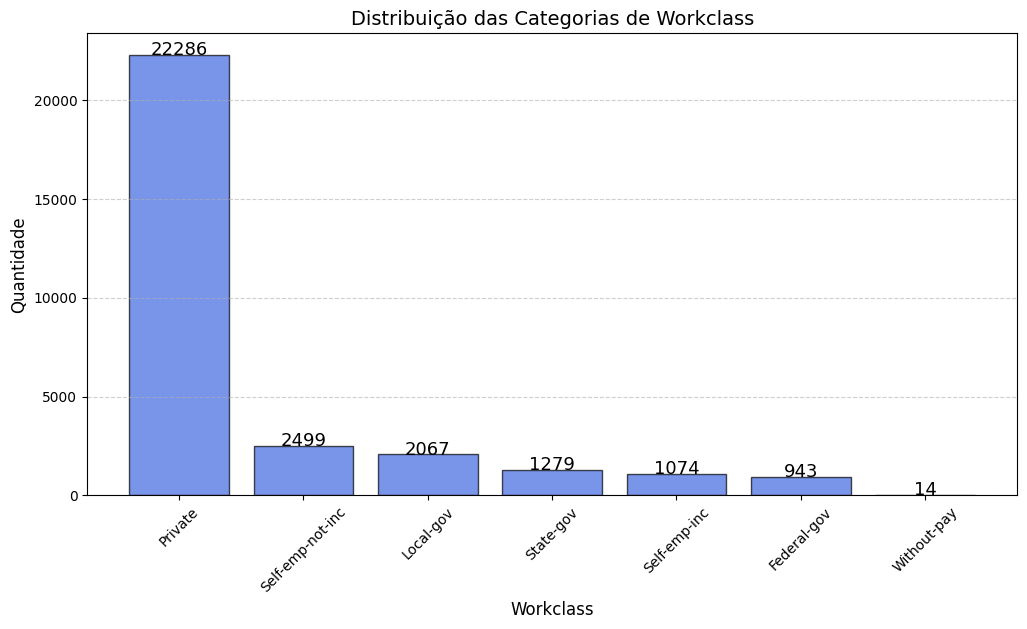

In [85]:
plt.figure(figsize=(12, 6))  # Largura = 20, Altura = 7
plt.bar(cont_worclass.index , cont_worclass.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Categorias de Workclass", fontsize=14)
plt.xlabel("Workclass", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(cont_worclass.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=13)
plt.show()

- O setor privado domina amplamente o mercado de trabalho representado neste dataset.

- O número significativo de autônomos (com ou sem empresa) indica um espaço importante para análises sobre empreendedorismo e informalidade.

- Os diferentes níveis do setor público (federal, estadual e local) mostram que o dataset abrange uma diversidade razoável de tipos de emprego governamental.

- As categorias com pouca representação (como without-pay) devem ser tratadas com cuidado na modelagem, pois podem introduzir ruído.

#### 4.3- fnlwgt : Peso final, representando o número de indivíduos que essa entrada do censo representa ####

##### 4.3.1- Resumo #####

- O fnlwgt é calculado com base em fatores como idade, sexo, raça e estado de residência.
- Na maioria dos casos, o fnlwgt não é útil para modelos de aprendizado de máquina, pois é um peso estatístico usado para análises demográficas, não uma característica preditiva.
- Em muitos casos, incluir essa variável pode adicionar ruído ao modelo, reduzindo sua capacidade de generalização.

**TESTAR IMPACTO**

- Rodar o modelo com e sem essa variável.
- Comparar métricas de desempenho.
- Avaliar se há ganho ou perda de precisão.


##### 4.3.2- Dados #####

In [86]:
dataset.fnlwgt.value_counts().sort_index()

fnlwgt
13769      1
14878      1
18827      1
19214      1
19302      5
          ..
1226583    1
1268339    1
1366120    1
1455435    1
1484705    1
Name: count, Length: 20263, dtype: int64

In [87]:
dataset.fnlwgt.describe()

count    3.016200e+04
mean     1.897938e+05
std      1.056530e+05
min      1.376900e+04
25%      1.176272e+05
50%      1.784250e+05
75%      2.376285e+05
max      1.484705e+06
Name: fnlwgt, dtype: float64

##### 4.3.3- Gráfico #####

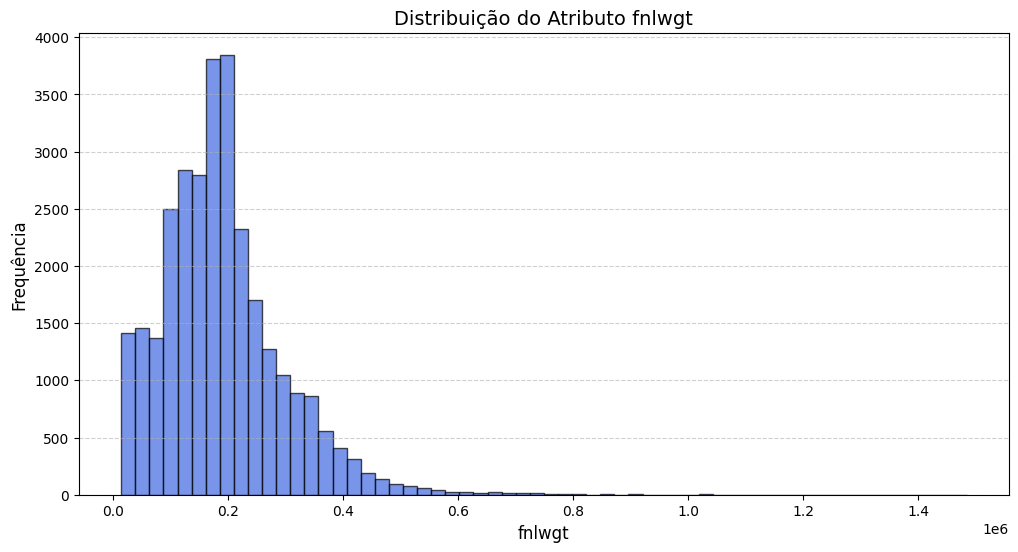

In [88]:
plt.figure(figsize=(12, 6)) 
plt.hist(dataset.fnlwgt , bins= 60,color='royalblue', edgecolor='black', alpha=0.7)

plt.title("Distribuição do Atributo fnlwgt", fontsize=14)
plt.xlabel("fnlwgt", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



#### 4.4- education: Nível de escolaridade do indivíduo ####


##### 4.4.1- Resumo #####

- Nível educacional mais alto alcançado por cada indivíduo. Ele é uma variável categórica.
- Indicador socioeconômico: O nível de educação pode estar fortemente correlacionado com a renda de uma pessoa.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.


##### 4.4.2- Dados #####

In [89]:
dataset.education.value_counts().sort_index()

education
10th             820
11th            1048
12th             377
1st-4th          151
5th-6th          288
7th-8th          557
9th              455
Assoc-acdm      1008
Assoc-voc       1307
Bachelors       5044
Doctorate        375
HS-grad         9840
Masters         1627
Preschool         45
Prof-school      542
Some-college    6678
Name: count, dtype: int64

##### 4.4.3- Gráfico #####

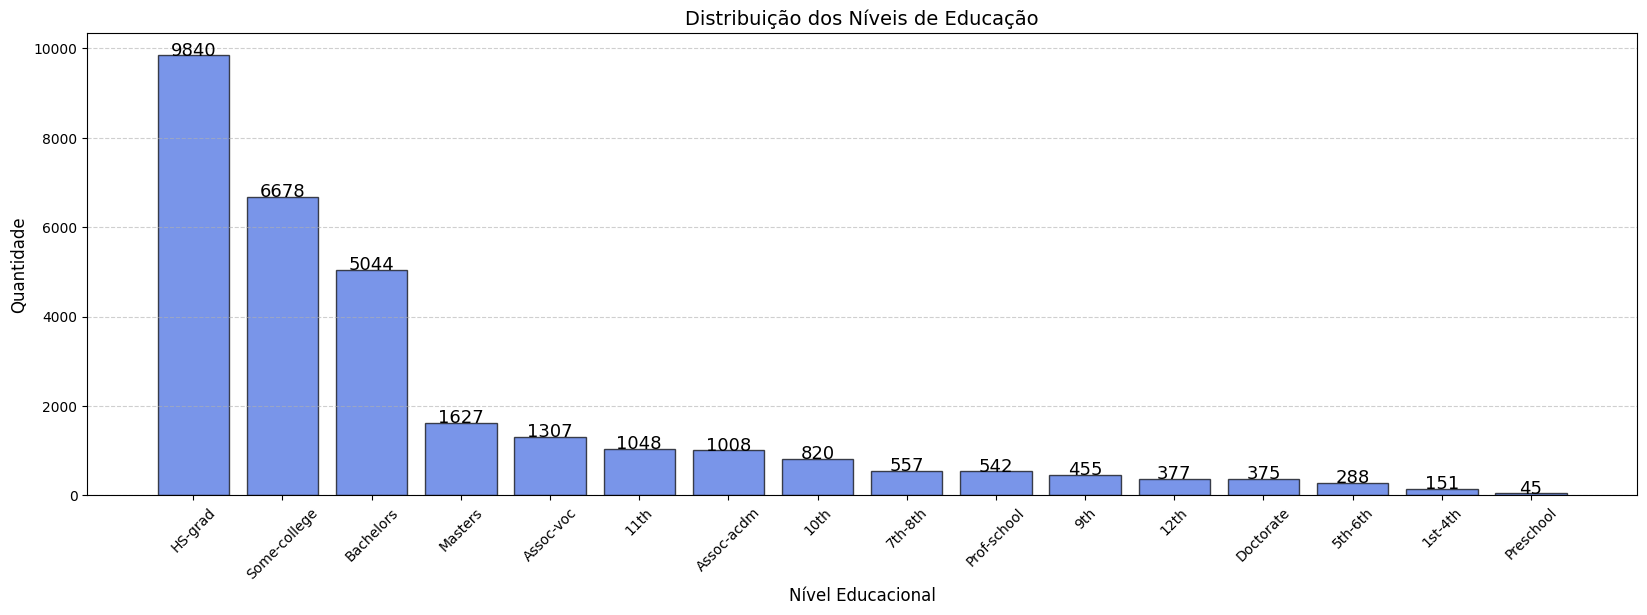

In [90]:
count_education = dataset.education.value_counts()
plt.figure(figsize=(20, 6))
plt.bar(count_education.index , count_education.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição dos Níveis de Educação", fontsize=14)
plt.xlabel("Nível Educacional", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_education.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=13)
plt.show()

Níveis mais comuns de escolaridade
- HS-grad (Ensino Médio completo): É o nível com maior número de indivíduos, totalizando 9840 pessoas. Isso indica que a maioria da população atingiu esse nível de escolaridade.

- Some-college (Algum tempo de faculdade, mas sem diploma): Vem em segundo lugar, com 6678 pessoas, sugerindo que muitos iniciam a educação superior, mas não concluem.

- Bachelors (Bacharelado): Com 5044 pessoas, é o terceiro nível mais comum.

#### 4.5- education-num: Número de anos de educação alcançados (contínuo) ####

##### 4.5.1- Resumo #####

Representa o nível educacional de uma pessoa em formato numérico. Ele é uma versão transformada da variável education

- Cada nível de educação recebe um número correspondente, facilitando a análise quantitativa.
- Por exemplo, Preschool pode ter um valor baixo (1), enquanto Doctorate pode ter um valor alto (16).
- Essa codificação permite que modelos de machine learning interpretem a educação como uma variável numérica, sem necessidade de conversão manual.

| education-num | education    |
| ------------- | ------------ |
| 1             | Preschool    |
| 2             | 1st-4th      |
| 3             | 5th-6th      |
| 4             | 7th-8th      |
| 5             | 9th          |
| 6             | 10th         |
| 7             | 11th         |
| 8             | 12th         |
| 9             | HS-grad      |
| 10            | Some-college |
| 11            | Assoc-voc    |
| 12            | Assoc-acdm   |
| 13            | Bachelors    |
| 14            | Masters      |
| 15            | Prof-school  |
| 16            | Doctorate    |


##### 4.5.2- Dados #####

In [91]:
dataset['education-num'].value_counts()

education-num
9     9840
10    6678
13    5044
14    1627
11    1307
7     1048
12    1008
6      820
4      557
15     542
5      455
8      377
16     375
3      288
2      151
1       45
Name: count, dtype: int64

In [92]:
dataset['education-num'].describe()

count    30162.000000
mean        10.121312
std          2.549995
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education-num, dtype: float64

##### 4.5.3- Gráfico #####

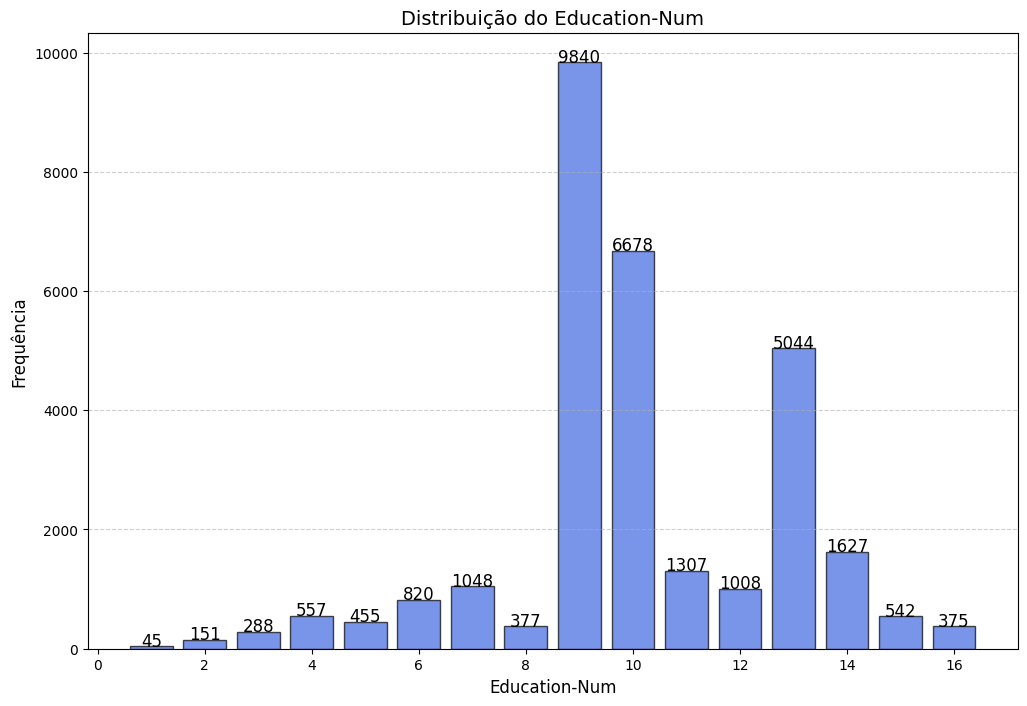

In [93]:
count_education_num = dataset['education-num'].value_counts().sort_index()
plt.figure(figsize=(12, 8))
plt.bar(count_education_num.index , count_education_num.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição do Education-Num", fontsize=14)
plt.xlabel("Education-Num", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_education_num.values):
    plt.text(count_education_num.index[i], valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()




Distribuição Centralizada no Ensino Médio
- O valor mais frequente é 9 (HS-grad) com 9840 ocorrências.

- Isso indica que a maioria dos adultos completou o ensino médio, mas não necessariamente avançou para o ensino superior.

- População majoritariamente educada até o ensino médio.

- Educação superior é comum, mas muitos não completam.

- Níveis muito baixos de educação (pré-escolar até 6ª série) são poucos.

#### 4.6- marital-status: Estado civil do indivíduo (categórico) ####

##### 4.6.1- Resumo #####

Representa o estado civil de cada indivíduo. Ele é uma variável categórica e pode incluir valores como:
- Never-married (Nunca casado)
- Married-civ-spouse (Casado legalmente)
- Divorced (Divorciado)
- Separated (Separado)
- Widowed (Viúvo)
- Married-spouse-absent (Casado, mas cônjuge ausente)
- Married-AF-spouse (Casado com cônjuge das Forças Armadas)


##### 4.6.2- Dados #####

In [94]:
dataset['marital-status'].value_counts().sort_index()

marital-status
Divorced                  4214
Married-AF-spouse           21
Married-civ-spouse       14065
Married-spouse-absent      370
Never-married             9726
Separated                  939
Widowed                    827
Name: count, dtype: int64

##### 4.6.3- Gráfico #####

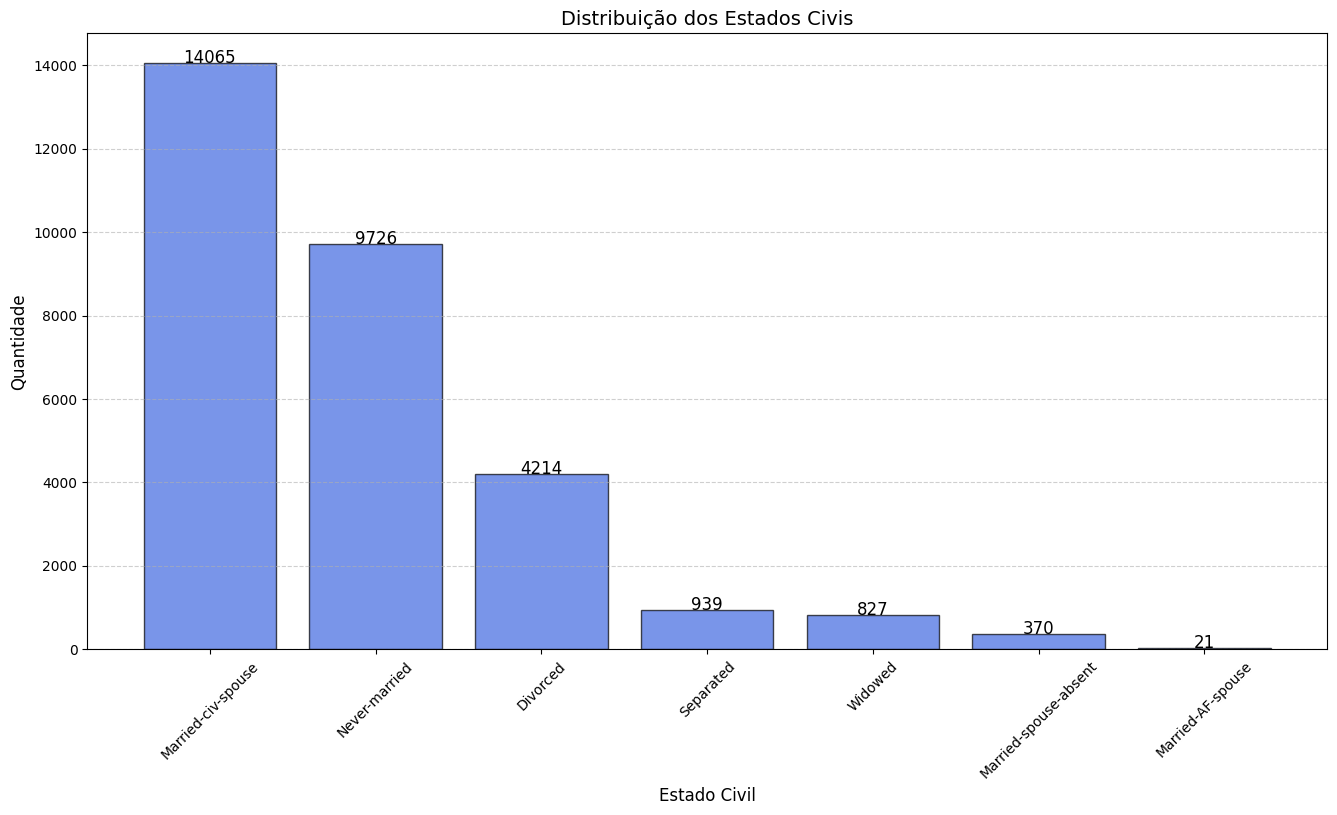

In [95]:
count_marital_status = dataset['marital-status'].value_counts()
plt.figure(figsize=(16, 8))
plt.bar(count_marital_status.index , count_marital_status.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição dos Estados Civis", fontsize=14)
plt.xlabel("Estado Civil", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_marital_status.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()


#### 4.7- occupation: Ocupação do indivíduo (categórico) ####

##### 4.7.1- Resumo #####

Representa a ocupação profissional de cada indivíduo. Ele é uma variável categórica e pode incluir valores como:

- Tech-support (Suporte técnico)
- Craft-repair (Reparo artesanal)
- Other-service (Outros serviços)
- Sales (Vendas)
- Exec-managerial (Executivo/gerencial)
- Prof-specialty (Profissional especializado)
- Handlers-cleaners (Manutenção/limpeza)
- Machine-op-inspct (Operador de máquinas/inspeção)
- Adm-clerical (Administrativo/escritório)
- Farming-fishing (Agricultura/pesca)
- Transport-moving (Transporte)
- Priv-house-serv (Serviço doméstico)
- Protective-serv (Serviço de segurança)
- Armed-Forces (Forças Armadas).



##### 4.7.2- Dados #####

In [96]:
dataset.occupation.value_counts().sort_values()

occupation
Armed-Forces            9
Priv-house-serv       143
Protective-serv       644
Tech-support          912
Farming-fishing       989
Handlers-cleaners    1350
Transport-moving     1572
Machine-op-inspct    1966
Other-service        3212
Sales                3584
Adm-clerical         3721
Exec-managerial      3992
Craft-repair         4030
Prof-specialty       4038
Name: count, dtype: int64

##### 4.7.3- Gráfico #####

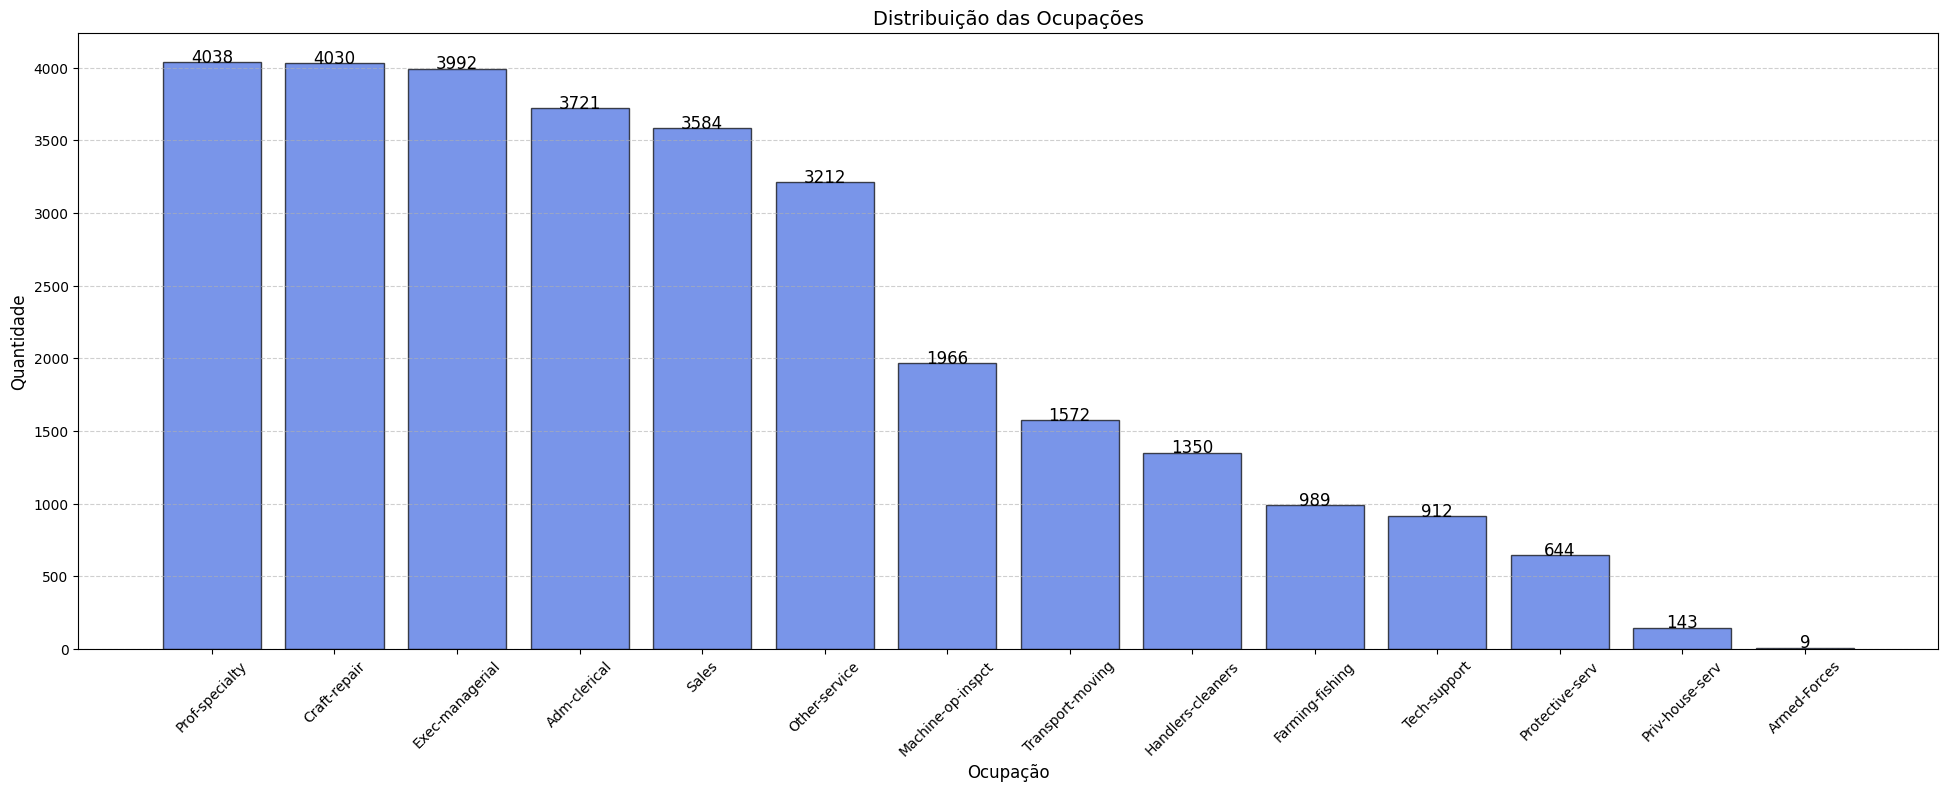

In [97]:
count_occupation = dataset.occupation.value_counts() 
plt.figure(figsize=(24, 8))
plt.bar(count_occupation.index , count_occupation.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Ocupações", fontsize=14)
plt.xlabel("Ocupação", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_occupation.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()


As três categorias com maior número de registros são:

- Prof-specialty (4038) :Profissões especializadas como médicos, engenheiros, professores, etc.

- Craft-repair (4030) : Ocupações técnicas/manuais, como mecânicos, encanadores, carpinteiros.

- Exec-managerial (3992) : Cargos de chefia, gestão e administração.
-- Provavelmente correlacionado com renda mais alta e maior escolaridade.

#### 4.8- relationship: Relação familiar do indivíduo (categórico) ####

##### 4.8.1- Resumo #####

Descreve o papel do indivíduo dentro de uma família ou residência. Ele é uma variável categórica e pode incluir valores como:
- Wife (Esposa)
- Husband (Marido)
- Own-child (Filho próprio)
- Unmarried (Solteiro)
- Other-relative (Outro parente)
- Not-in-family (Não pertence a uma família)


Importância do atributo relationship
- Pode influenciar a renda: Pessoas casadas (como Husband e Wife) podem ter maior estabilidade financeira e, possivelmente, rendas mais altas.
- Complementa marital-status: Junto com o estado civil, ajuda a entender melhor a estrutura familiar do indivíduo.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.


##### 4.8.2- Dados #####

In [98]:
dataset.relationship.value_counts().sort_values()

relationship
Other-relative      889
Wife               1406
Unmarried          3212
Own-child          4466
Not-in-family      7726
Husband           12463
Name: count, dtype: int64

##### 4.8.3- Gráfico #####

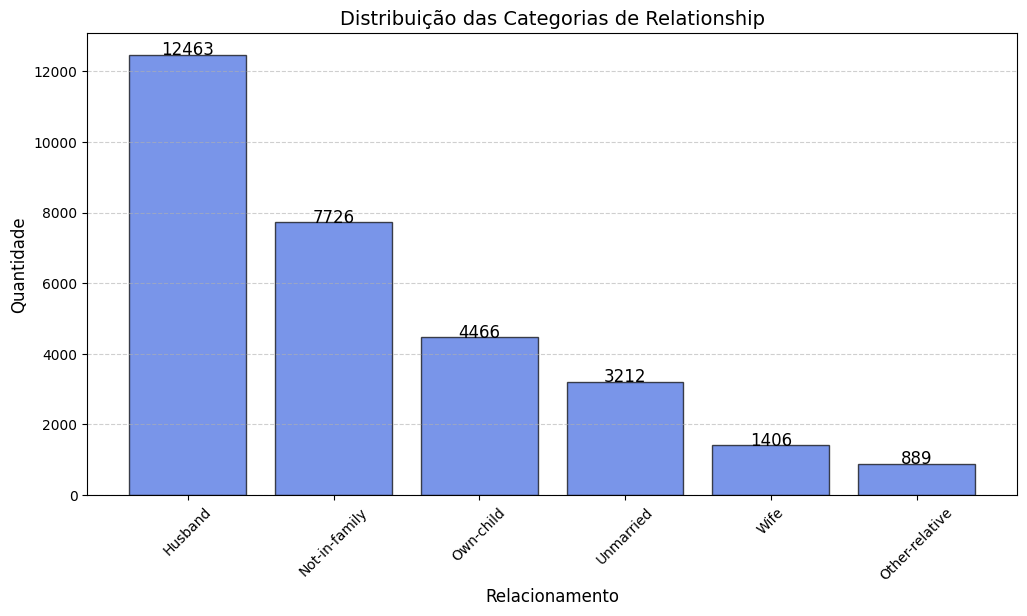

In [99]:
count_relationship = dataset.relationship.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(count_relationship.index , count_relationship.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Categorias de Relationship", fontsize=14)
plt.xlabel("Relacionamento", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_relationship.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()


Categorias mais frequentes
- Husband (12463): Representa a maior parte dos registros. Indica que a maioria dos indivíduos na base são homens casados, e provavelmente chefes de família.

- Not-in-family (7726): Indivíduos vivendo sozinhos ou em casas compartilhadas, sem relação familiar com os demais. Pode incluir jovens, solteiros ou pessoas que dividem moradia.

- Own-child (4466): Pessoas que são filhos ou filhas do chefe da família. Provavelmente pessoas mais jovens, em idade escolar ou início da vida adulta.

Interpretação
- Predominância de homens casados como chefes de família sugere uma estrutura familiar tradicional no dataset.

- Alta proporção de pessoas fora de núcleos familiares diretos (Not-in-family + Own-child) pode indicar: Jovens adultos vivendo sozinhos.

 - Baixa presença de mulheres na posição de esposa (wife) em relação a “husband” reforça viés historico do genero no mercado de trabalho.

#### 4.9 race: Raça do indivíduo (categórico) ####

##### 4.9.1- Resumo #####

Representa a raça declarada de cada indivíduo. Ele é uma variável categórica e pode incluir valores como:
- White (Branco)
- Black (Negro)
- Asian-Pac-Islander (Asiático ou das Ilhas do Pacífico)
- Amer-Indian-Eskimo (Indígena Americano ou Esquimó)
- Other (Outra)


- Pode influenciar a renda: Em algumas análises socioeconômicas, diferenças de renda podem ser observadas entre grupos raciais devido a fatores históricos e estruturais.
- Relevante para estudos de equidade: Essa variável pode ser usada para investigar disparidades salariais e possíveis vieses em modelos de aprendizado de máquina.
- Pode estar correlacionada com outras variáveis: Como ocupação, educação e estado civil.


##### 4.9.2- Dados #####

In [100]:
dataset.race.value_counts().sort_values()

race
Other                   231
Amer-Indian-Eskimo      286
Asian-Pac-Islander      895
Black                  2817
White                 25933
Name: count, dtype: int64

##### 4.9.3- Gráfico #####

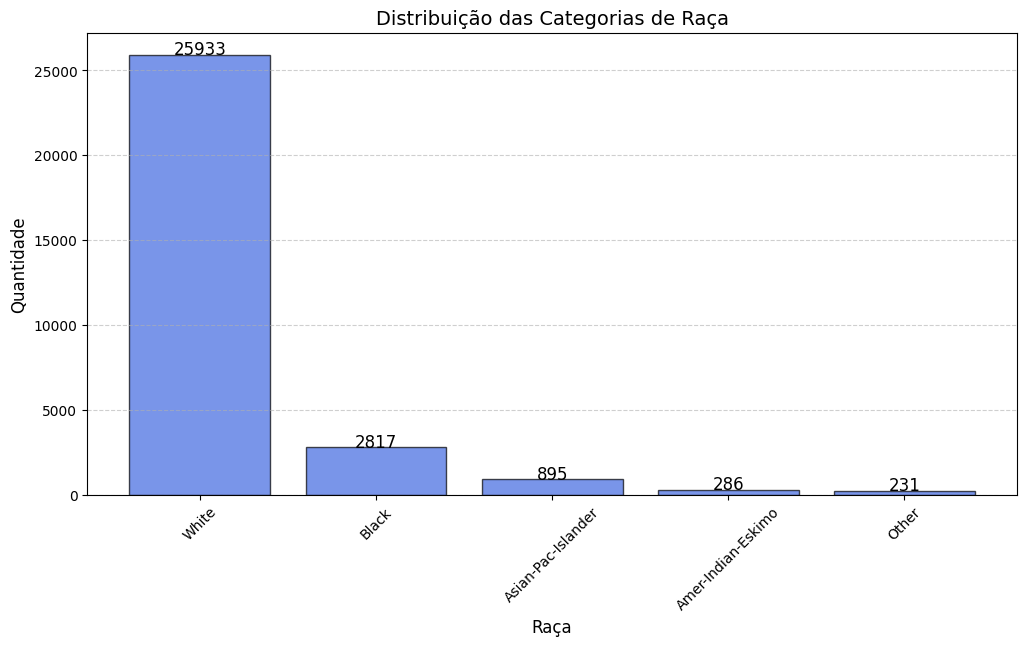

In [101]:
count_race = dataset.race.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(count_race.index , count_race.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Categorias de Raça", fontsize=14)
plt.xlabel("Raça", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, valor in enumerate(count_race.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()

Categorias e Frequências
1. White — 25933 registros

- Claramente dominante no conjunto de dados.

- Representa a maior parte da população da base, o que pode introduzir viés estatístico nas análises.

2. Black — 2817 registros 

- Segunda maior categoria.

- Presença significativa, mas ainda substancialmente menor que a categoria majoritária.

3. Asian-Pac-Islander — 895 registros 

- Representação modesta.

- Pode ser importante analisar essa categoria separadamente por questões culturais e de renda.

4. Amer-Indian-Eskimo — 286 registros 

- Minoria expressiva, mas pequena em termos absolutos.

- Pode ser difícil tirar conclusões estatisticamente significativas com essa amostra.

5. Other — 231 registros 

- Categoria genérica que abrange demais grupos não especificados.

- Uso dessa categoria pode ocultar diversidades relevantes.

#### 4.10 sex: Sexo do indivíduo (categórico) ####

##### 4.10.1- Resumo #####

 Representa o gênero do indivíduo e é uma variável binária com os valores:
- Male (Masculino)
- Female (Feminino)


Importância do atributo sex
- Pode influenciar a renda: Estudos mostram que há diferenças salariais entre homens e mulheres em diversas áreas profissionais.
- Relevante para análises de equidade: Essa variável pode ser usada para investigar disparidades salariais e possíveis vieses em modelos de aprendizado de máquina.
- Pode estar correlacionada com outras variáveis: Como ocupação, horas trabalhadas por semana e estado civil.


##### 4.10.2- Dados #####

In [102]:
dataset.sex.value_counts().sort_values()

sex
Female     9782
Male      20380
Name: count, dtype: int64

##### 4.10.3- Gráfico #####

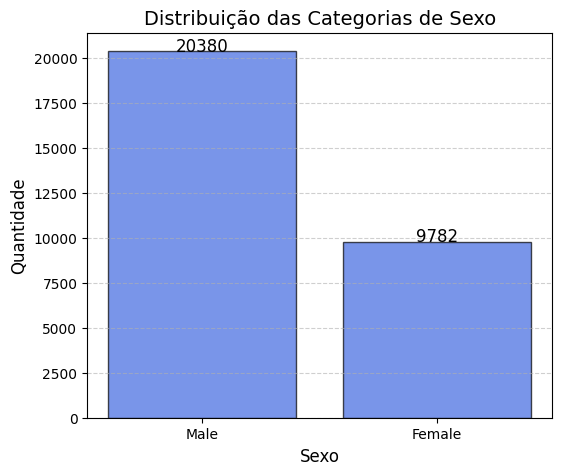

In [103]:
count_sex = dataset.sex.value_counts()
plt.figure(figsize=(6, 5))
plt.bar(count_sex.index , count_sex.values,color='royalblue', edgecolor='black', alpha = 0.7)
plt.title("Distribuição das Categorias de Sexo", fontsize=14)
plt.xlabel("Sexo", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_sex.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()

- A amostra possui o dobro de homens em relação às mulheres.

- Esse desbalanceamento pode afetar modelos preditivos, especialmente em tarefas como classificação de renda, pois:

    - O modelo pode ser mais preciso para o grupo majoritário (homens).

    - Há risco de viés algorítmico, favorecendo um gênero.

- Quando cruzado com a variável income, o atributo sex pode revelar disparidades salariais entre homens e mulheres.

- Isso permite investigar questões de desigualdade de gênero no mercado de trabalho.

#### 4.11- capital-gain: Ganho de capital (contínuo) ####

##### 4.11.1- Resumo #####

Representa o ganho de capital de um indivíduo, ou seja, a renda obtida a partir da venda de ativos como ações, imóveis ou outros investimentos.
Importância do atributo capital-gain
- Pode influenciar a renda total: Pessoas que têm ganhos de capital elevados podem ter uma renda significativamente maior.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e idade.


##### 4.11.2- Dados #####

In [104]:
dataset['capital-gain'].describe()

count    30162.000000
mean      1092.007858
std       7406.346497
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

1. Distribuição Extremamente Assimétrica
- Mediana = 0, e 75% dos dados são 0 — ou seja, mais de 75% das pessoas não tiveram nenhum ganho de capital.

- Isso indica uma distribuição altamente enviesada à direita, com muitos zeros e poucos valores muito altos.

2. Presença de Outliers
- O valor máximo de 99.999 é extremamente alto e bem distante da média (1.077) e do desvio padrão (7.385), indicando outliers severos.


##### 4.11.3- Gráfico #####

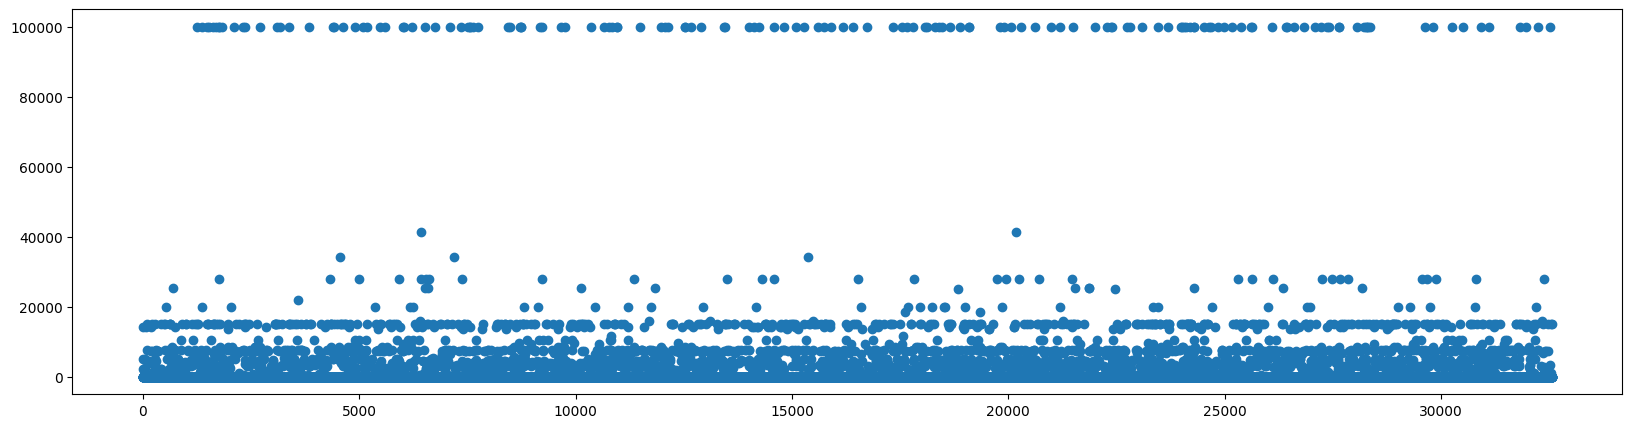

In [105]:
plt.figure(figsize=(20, 5))
plt.scatter(dataset['capital-gain'].index , dataset['capital-gain'].values)
plt.show()

- O alto número de zeros pode distorcer análises estatísticas e modelos preditivos.

- O uso dessa variável sem tratamento pode prejudicar desempenho de modelos e mascarar padrões reais.

#### 4.12- capital-loss: Perda de capital (contínuo) ####

##### 4.12.1- Resumo #####

Representa as perdas de capital de um indivíduo, ou seja, o valor perdido em investimentos, como ações ou imóveis, durante o ano.
Importância do atributo capital-loss
- Pode influenciar a renda total: Pessoas que tiveram perdas de capital podem ter uma renda líquida menor.
- Relevante para modelos de machine learning: Assim como capital-gain, essa variável pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e idade.


##### 4.12.2- Dados #####

In [106]:
dataset['capital-loss'].describe()

count    30162.000000
mean        88.372489
std        404.298370
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Distribuição Extremamente Assimétrica
- Assim como na variável capital-gain, os valores de capital-loss são majoritariamente zero:

    - Mediana = 0

    - 75% dos valores são 0

- Isso indica que a grande maioria das pessoas não registrou perda de capital.

##### 4.12.3- Gráfico #####

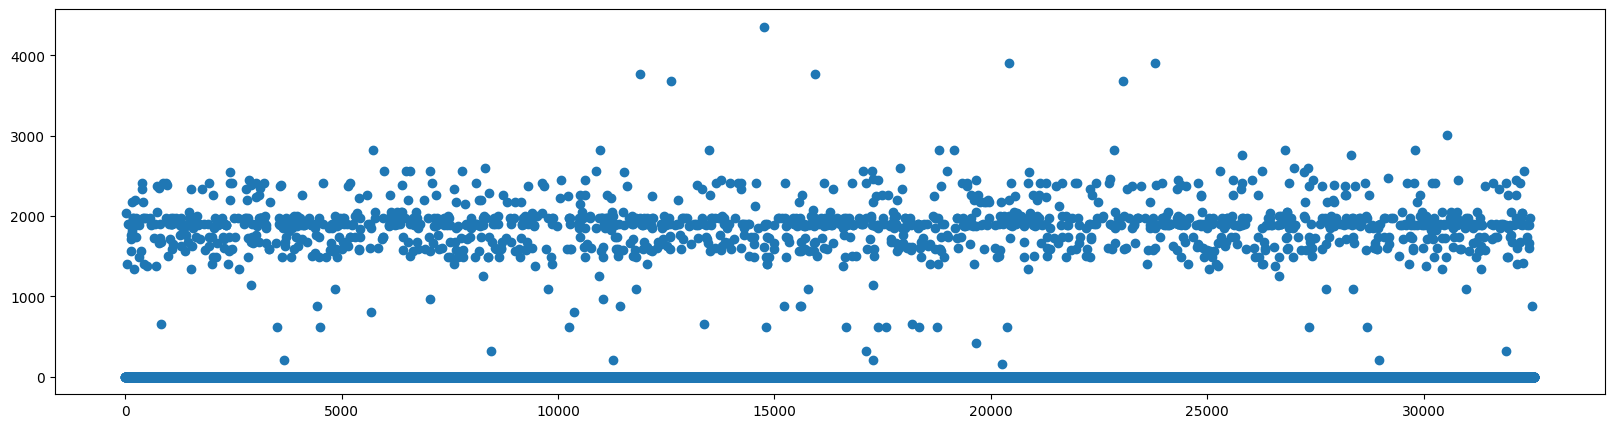

In [107]:
plt.figure(figsize=(20, 5))
plt.scatter(dataset['capital-loss'].index , dataset['capital-loss'].values)
plt.show()

#### 4.13- hours-per-week: Número de horas trabalhadas por semana (contínuo)  ####

##### 4.13.1- Resumo ##### 

Representa o número de horas que um indivíduo trabalha por semana. Ele é uma variável numérica contínua e pode variar bastante entre os registros.
Importância do atributo hours-per-week
- Pode influenciar a renda: Pessoas que trabalham mais horas por semana podem ter maior renda, especialmente em empregos que pagam por hora.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e estado civil.

##### 4.13.2- Dados #####

In [108]:
dataset['hours-per-week'].value_counts()

hours-per-week
40    14251
50     2718
45     1753
60     1405
35     1184
      ...  
87        1
82        1
94        1
92        1
74        1
Name: count, Length: 94, dtype: int64

In [109]:
dataset['hours-per-week'].describe()

count    30162.000000
mean        40.931238
std         11.979984
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

1. Forte Concentração em 40 Horas
- 25%, 50% e média estão todas em torno de 40 horas.

- Isso indica que o valor 40 horas por semana é o mais comum — provavelmente porque representa a jornada de trabalho padrão em muitos empregos formais.

- O valor máximo é 99, bem acima da média e dos quartis — o que sugere a presença de outliers (trabalhadores com carga horária excessiva).

- O mínimo de 1 hora também sugere a presença de pessoas com trabalho parcial, informal ou eventual.

##### 4.13.3- Gráfico #####

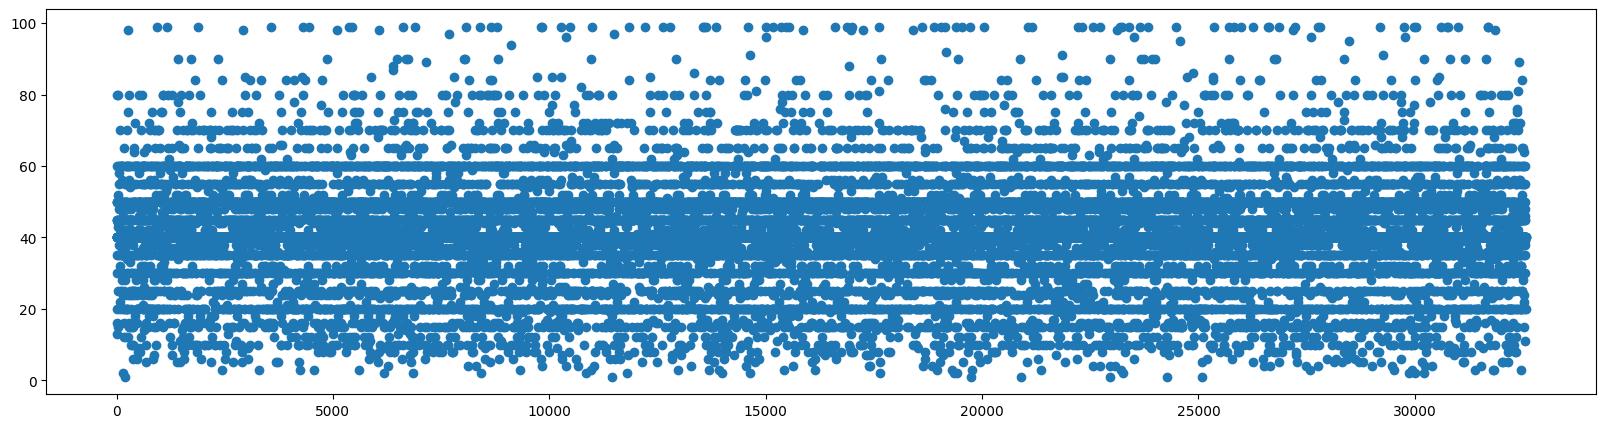

In [110]:
plt.figure(figsize=(20, 5))
plt.scatter(dataset['hours-per-week'].index , dataset['hours-per-week'].values)
plt.show()

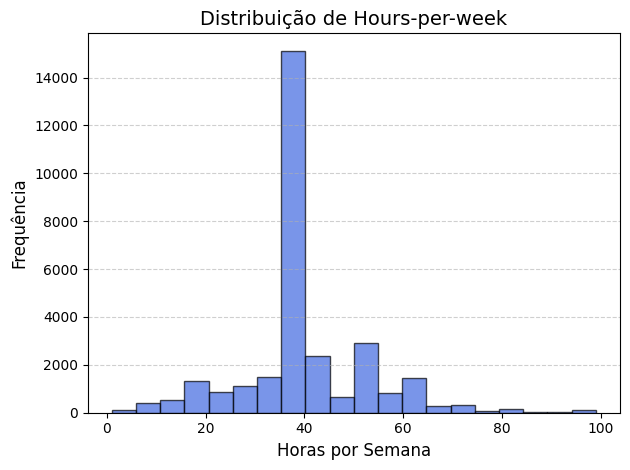

In [111]:
plt.hist(dataset['hours-per-week'], bins= 20, color='royalblue', edgecolor='black', alpha=0.7)

# Adicionando título e rótulos
plt.title("Distribuição de Hours-per-week", fontsize=14)
plt.xlabel("Horas por Semana", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

# Ajustando o estilo do grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

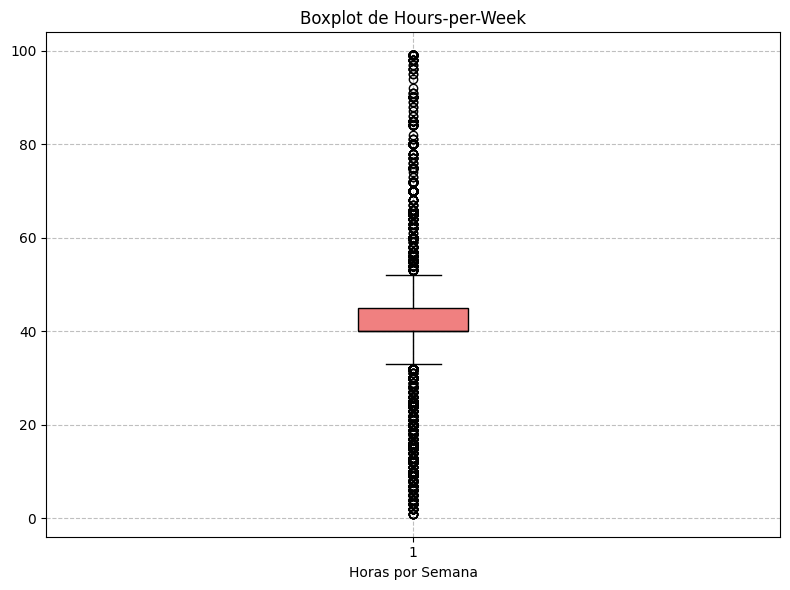

In [112]:
plt.figure(figsize=(8, 6))
plt.boxplot(dataset['hours-per-week'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='black'),
            medianprops=dict(color='black'))
plt.title('Boxplot de Hours-per-Week')
plt.xlabel('Horas por Semana')
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

#### 4.14- native-country: País de origem do indivíduo (categórico) ####

##### 4.14.1- Resumo #####

Representa o país de origem do indivíduo. Possui 42 categorias distintas. Ele é uma variável categórica e pode incluir valores como:
- United-States (Estados Unidos)
- Mexico (México)
- Canada (Canadá)
- Germany (Alemanha)
- Philippines (Filipinas)
- India (Índia)
- China (China)
- Other (Outro país)



Importância do atributo native-country
- Pode influenciar a renda: O país de origem pode estar relacionado a oportunidades econômicas e acesso ao mercado de trabalho.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante, especialmente em estudos sobre imigração e impacto socioeconômico.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e capital-gain.


##### 4.14.2- Dados #####

In [113]:
dataset['native-country'].value_counts().sort_index()

native-country
Cambodia                         18
Canada                          107
China                            68
Columbia                         56
Cuba                             92
Dominican-Republic               67
Ecuador                          27
El-Salvador                     100
England                          86
France                           27
Germany                         128
Greece                           29
Guatemala                        63
Haiti                            42
Holand-Netherlands                1
Honduras                         12
Hong                             19
Hungary                          13
India                           100
Iran                             42
Ireland                          24
Italy                            68
Jamaica                          80
Japan                            59
Laos                             17
Mexico                          610
Nicaragua                        33
Outlying-US(G

##### 4.14.3- Gráfico #####

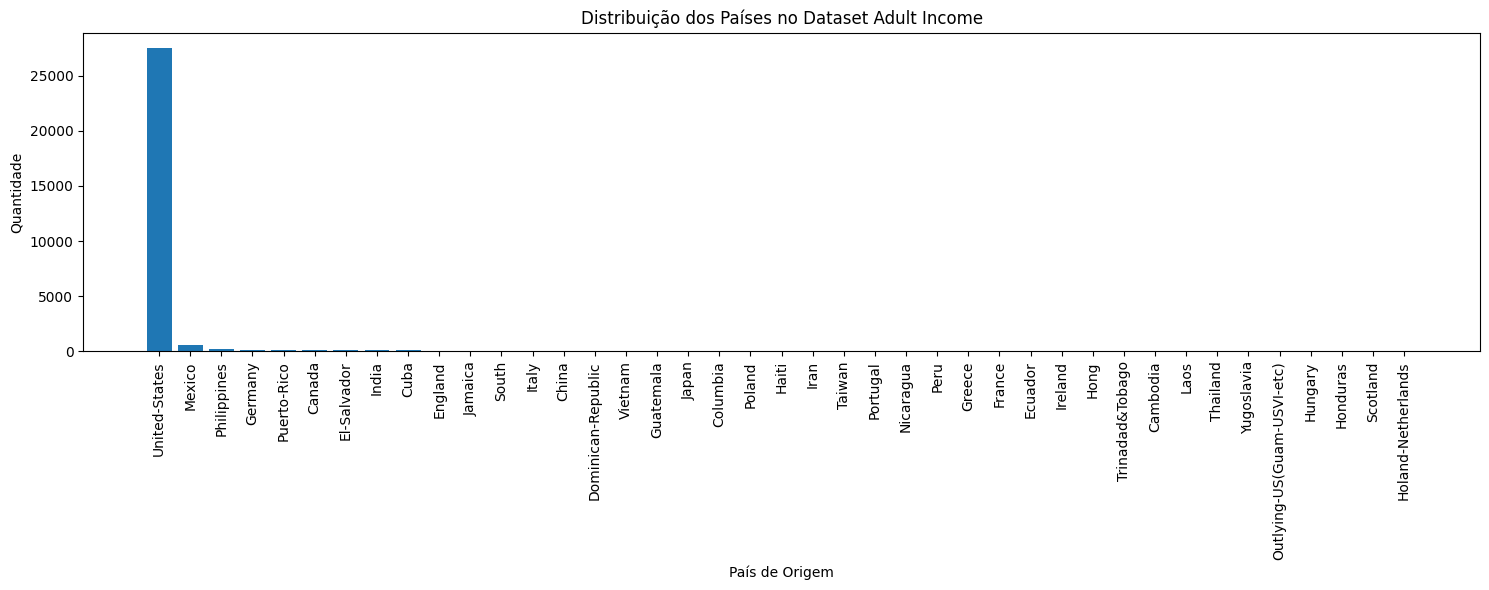

In [114]:
# Contagem dos países
count_native_country = dataset["native-country"].value_counts()

# Criando o gráfico
plt.figure(figsize=(15, 6))
plt.bar(count_native_country.index, count_native_country.values)

# Rotacionando os nomes dos países para melhor visualização
plt.xticks(rotation=90)
plt.xlabel("País de Origem")
plt.ylabel("Quantidade")
plt.title("Distribuição dos Países no Dataset Adult Income")
plt.tight_layout()
plt.show()

- Estados Unidos (United-States) domina o conjunto de dados:

    - Com cerca de 29.000 registros, representa uma massiva maioria dos dados.

    - Isso indica que o dataset tem um forte viés geográfico, voltado para a realidade norte-americana.

- Outros países aparecem em quantidades extremamente reduzidas:

    - México, Filipinas, Alemanha e Canadá aparecem, mas com frequência muito pequena.

    - A maioria dos demais países tem menos de 100 registros cada.

#### 4.15- income: Variável alvo (categórico) ####

##### 4.15.1- Resumo #####

É a variável-alvo do conjunto de dados. Ele indica se um indivíduo ganha mais ou menos de 50K por ano, sendo uma variável categórica binária com os seguintes valores:
- <=50K: Indivíduos que ganham até 50 mil dólares por ano.
- >50K: Indivíduos que ganham mais de 50 mil dólares por ano.


##### 4.15.2- Dados #####

In [115]:
dataset.income.value_counts()

income
<=50K    22654
>50K      7508
Name: count, dtype: int64

In [116]:
print(f'O percentual de pessoal que ganham >50K é : {((dataset['income'] == '>50K').sum() / dataset['income'].count()*100)}')
print(f'O percentual de pessoal que ganham <=50K é : {((dataset['income'] != '>50K').sum() / dataset['income'].count()*100)}')


O percentual de pessoal que ganham >50K é : 24.892248524633644
O percentual de pessoal que ganham <=50K é : 75.10775147536636


##### 4.15.3- Gráfico #####

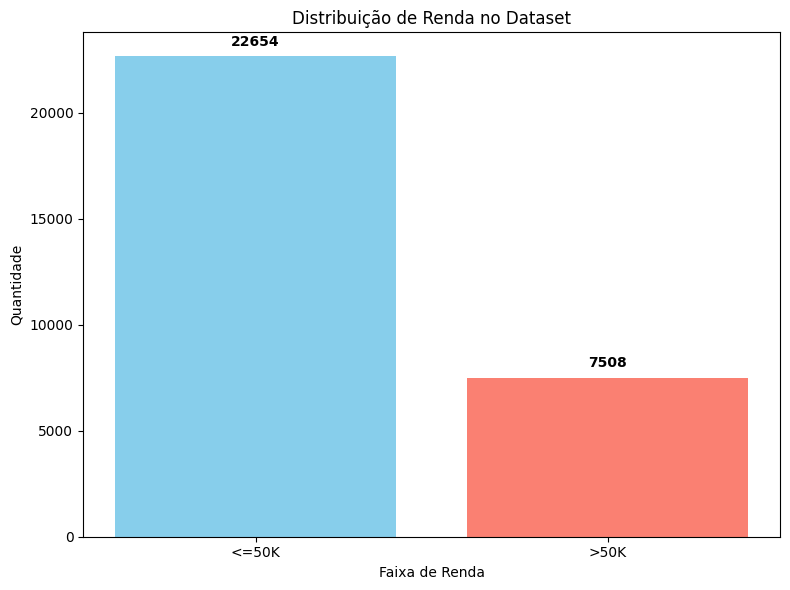

In [117]:
# Contagem das classes de income
count_income = dataset['income'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(count_income.index, count_income.values, color=['skyblue', 'salmon'])

# Adiciona os rótulos
for i, v in enumerate(count_income.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

# Configurações
plt.xlabel("Faixa de Renda")
plt.ylabel("Quantidade")
plt.title("Distribuição de Renda no Dataset")
plt.tight_layout()
plt.show()


### 5.-**Resumo dos Atributos**

Com base nas análises que você já foram feitas até aqui (gráficos, estatísticas e distribuição de dados), abaixo são as considerações que vamos com os atributos antes de aplicar os algoritmos de classificação 
1. Atributos a MANTER (com ou sem pré-processamento):
- age , hours-per-week: -> normalizar.

- education,workclass,marital-status, occupation, relationship, race, sex, native-country: -> Transformar em numérico.

- income: Target. JManter com está.

2. Atributos a MODIFICAR:
- capital-gain / capital-loss:

    - Altamente enviesados (muitos zeros, poucos valores altos).


- Criar uma variável binária indicando se teve ganho/perda (capital_gain_flag).

3. Atributos a EXCLUIR (opcional):

- fnlwgt: como visto variável estatisica sem muita relevância

### 6.-**Transformação dos Atributos**

#### 6.1- ***Transformando os atributos 'capital-gain' e 'capital-loss' em variáveis binárias***



*Mapeamento*
- capital-gain → 1 se > 0, senão 0

- capital-loss → 1 se > 0, senão 0

In [118]:
# Cria uma cópia do dataset original
dataset2 = dataset.copy()
# Capital Gain: 1 se teve ganho, 0 se não teve
dataset2['capital_gain_bin'] = dataset2['capital-gain'].apply(lambda x: 1 if x > 0 else 0)

# Capital Loss: 1 se teve perda, 0 se não teve
dataset2['capital_loss_bin'] = dataset2['capital-loss'].apply(lambda x: 1 if x > 0 else 0)

#  removendo as colunas originais
dataset2.drop(['capital-gain', 'capital-loss'], axis=1, inplace=True)
dataset2.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income,capital_gain_bin,capital_loss_bin
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,1,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,0,0


#### 6.2- ***Excluindo o atributo 'fnlwgt'***

In [119]:
dataset2.drop('fnlwgt', axis=1, inplace=True)
dataset2.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income,capital_gain_bin,capital_loss_bin
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,1,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,0,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,0,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,0,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,0,0


#### 6.3- ***Transformar os atributos categóricos em numericos***

In [120]:
# Lista das colunas categóricas
colunas_categoricas = [
    'education', 'workclass', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'native-country'
]

# Aplicando LabelEncoder e exibindo os mapeamentos
for col in colunas_categoricas:
    le = LabelEncoder()
    dataset2[col] = le.fit_transform(dataset2[col])
    
    # Mostrar mapeamento
    mapeamento = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'\nCodificação da coluna "{col}":')
    for categoria, codigo in mapeamento.items():
        print(f'  {categoria} -> {codigo}')


Codificação da coluna "education":
  10th -> 0
  11th -> 1
  12th -> 2
  1st-4th -> 3
  5th-6th -> 4
  7th-8th -> 5
  9th -> 6
  Assoc-acdm -> 7
  Assoc-voc -> 8
  Bachelors -> 9
  Doctorate -> 10
  HS-grad -> 11
  Masters -> 12
  Preschool -> 13
  Prof-school -> 14
  Some-college -> 15

Codificação da coluna "workclass":
  Federal-gov -> 0
  Local-gov -> 1
  Private -> 2
  Self-emp-inc -> 3
  Self-emp-not-inc -> 4
  State-gov -> 5
  Without-pay -> 6

Codificação da coluna "marital-status":
  Divorced -> 0
  Married-AF-spouse -> 1
  Married-civ-spouse -> 2
  Married-spouse-absent -> 3
  Never-married -> 4
  Separated -> 5
  Widowed -> 6

Codificação da coluna "occupation":
  Adm-clerical -> 0
  Armed-Forces -> 1
  Craft-repair -> 2
  Exec-managerial -> 3
  Farming-fishing -> 4
  Handlers-cleaners -> 5
  Machine-op-inspct -> 6
  Other-service -> 7
  Priv-house-serv -> 8
  Prof-specialty -> 9
  Protective-serv -> 10
  Sales -> 11
  Tech-support -> 12
  Transport-moving -> 13

Codificaçã

In [121]:
# Reorganizar as colunas para que 'income' fique por último
colunas = [col for col in dataset2.columns if col != 'income']
colunas.append('income')
dataset2 = dataset2[colunas]

dataset2.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,capital_gain_bin,capital_loss_bin,income
0,39,5,9,13,4,0,1,4,1,40,38,1,0,<=50K
1,50,4,9,13,2,3,0,4,1,13,38,0,0,<=50K
2,38,2,11,9,0,5,1,4,1,40,38,0,0,<=50K
3,53,2,1,7,2,5,0,2,1,40,38,0,0,<=50K
4,28,2,9,13,2,9,5,2,0,40,4,0,0,<=50K


#### 6.4- ***Transformando o Target -> 'income' em binário***

In [122]:
print(dataset2['income'].unique())


['<=50K' '>50K']


In [123]:
# Transformando a variável income diretamente no dataset2
dataset2['income'] = dataset2['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)



In [124]:
dataset2.income.value_counts()

income
0    22654
1     7508
Name: count, dtype: int64

### 7.- ***MODIFICAÇÕES REALIZADAS NO DATASET ORIGINAL***

1. Resumo das Modificações Realizadas:
Atributo	Ação Realizada
- fnlwgt	→    Removido
- capital-gain	Transformado em binário → capital_gain_bin
- capital-loss	Transformado em binário → capital_loss_bin
- Atributos categóricos (education, workclass, etc.)	Codificados com LabelEncoder
- income Transformado em binário


Validação :

- Todas as variáveis numéricas (inteiras ou binárias);

- Nenhum valor nulo (por conta do dropna);

- Atributo alvo (income) com duas classes: <=50K e >50K.



In [125]:
dataset2.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,capital_gain_bin,capital_loss_bin,income
0,39,5,9,13,4,0,1,4,1,40,38,1,0,0
1,50,4,9,13,2,3,0,4,1,13,38,0,0,0
2,38,2,11,9,0,5,1,4,1,40,38,0,0,0
3,53,2,1,7,2,5,0,2,1,40,38,0,0,0
4,28,2,9,13,2,9,5,2,0,40,4,0,0,0


In [126]:
dataset2.dtypes

age                 int64
workclass           int64
education           int64
education-num       int64
marital-status      int64
occupation          int64
relationship        int64
race                int64
sex                 int64
hours-per-week      int64
native-country      int64
capital_gain_bin    int64
capital_loss_bin    int64
income              int64
dtype: object

In [127]:
dataset2.describe()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,capital_gain_bin,capital_loss_bin,income
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,2.199324,10.333764,10.121312,2.580134,5.959850,1.418341,3.678602,0.675685,40.931238,36.382567,0.084146,0.047311,0.248922
std,13.134665,0.953925,3.812292,2.549995,1.498016,4.029566,1.601338,0.834709,0.468126,11.979984,6.105372,0.277611,0.212307,0.432396
min,17.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,2.000000,9.000000,9.000000,2.000000,2.000000,0.000000,4.000000,0.000000,40.000000,38.000000,0.000000,0.000000,0.000000
50%,37.000000,2.000000,11.000000,10.000000,2.000000,6.000000,1.000000,4.000000,1.000000,40.000000,38.000000,0.000000,0.000000,0.000000
75%,47.000000,2.000000,12.000000,13.000000,4.000000,9.000000,3.000000,4.000000,1.000000,45.000000,38.000000,0.000000,0.000000,0.000000
max,90.000000,6.000000,15.000000,16.000000,6.000000,13.000000,5.000000,4.000000,1.000000,99.000000,40.000000,1.000000,1.000000,1.000000


### 8.- **Salvando (Exportando) o Dataframe Tratado**

In [128]:
dataset2.to_csv('adult_income_tratado.csv', sep=';', index=False)